In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix

In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# Set the global random seed for reproducibility
np.random.seed(0)

In [4]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')
root_folder = '/content/drive/MyDrive/OIST-mini-course'
!ls $root_folder

Mounted at /content/drive
cls_train-1.pkl
cls_train.pkl
cls_val-1.pkl
cls_val.pkl
code001_setup_part-A.ipynb
code001_setup_part-B.ipynb
code001_setup_readme.pdf
code002_data_prep_NN.ipynb
code003_LogReg.ipynb
code004_DNN_scratch.ipynb
code005_part-A_detection_dataPrep.ipynb
code005_part-B_pollen_detection_model_design.ipynb
code005_part-C_pollen_detection_training.ipynb
code006_part-A_DNN_finetune.ipynb
code006_part-B_pollen_detection_finetune.ipynb
dataset_for_classification
dataset_for_classification-1
dataset_for_classification-1.zip
dataset_for_classification.zip
dataset_for_detection
dataset_for_detection.zip
det_trainval_splits.pkl
meta_detection.pkl
slides
test-image.jpg
test-image-sharpened.jpg


# load the train&val sets

In [5]:
filename_train = os.path.join(root_folder, 'cls_train.pkl')
filename_val = os.path.join(root_folder, 'cls_val.pkl')

In [6]:
with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

In [7]:
train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

In [8]:
len(trainset_info['train_imgpathlist']), len(valset_info['val_imgpathlist'])


(480, 120)

In [9]:
val_imgs = []
i = 0
for curname in valset_info['val_imgpathlist']:
    im = skimage.io.imread(curname)
    val_imgs += [im.astype(np.float32)]
    i+=1
    if i%100==0:
        print(i, len(valset_info['val_imgpathlist']))

100 120


In [10]:
train_imgs = []

i = 0
for curname in trainset_info['train_imgpathlist']:
    im = skimage.io.imread(curname)
    train_imgs += [im.astype(np.float32)]
    i+=1
    if i%100==0:
        print(i, len(trainset_info['train_imgpathlist']))




100 480
200 480
300 480
400 480


# Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

In [12]:
for i in range(len(train_imgs)):
    im = train_imgs[i]
    im = np.reshape(im,(1,-1))
    train_imgs[i] = im

for i in range(len(val_imgs)):
    im = val_imgs[i]
    im = np.reshape(im,(1,-1))
    val_imgs[i] = im

In [13]:
train_imgs = np.asarray(train_imgs).squeeze()
val_imgs = np.asarray(val_imgs).squeeze()

train_labellist = np.asarray(train_labellist)
val_labellist = np.asarray(val_labellist)

print(train_imgs.shape)
print(train_labellist.shape)

print(val_imgs.shape)
print(val_labellist.shape)

(480, 458643)
(480,)
(120, 458643)
(120,)


In [14]:
clf = LogisticRegression(max_iter=1000).fit(train_imgs, train_labellist)

In [15]:
predList = clf.predict(val_imgs)

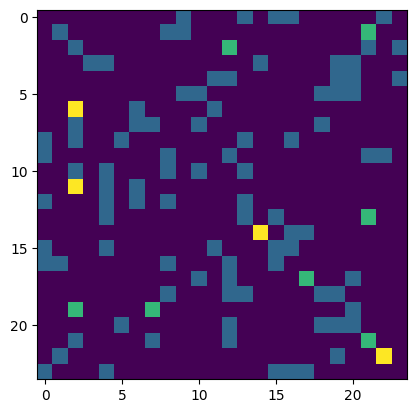

In [16]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')
plt.imshow(conf)

In [17]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.167
